# Exercise  2 - LTI systems

## Objectives
- To investigate properties of LTI systems
- To learn about the different representations of LTI systems
- To understand the concept of convolution


In [1]:
import os
os.makedirs('results/ex2', exist_ok=True)

## Lab Exercise

### Impulse response representation
<img src="img/ex2b_1.svg" alt="Drawing" style="width: 900px;"/>
<center>Figure 2.1: Impulse response of a LTI system</center>

Suppose we apply a unit impulse function, $\delta[n]$, as an input to a Linear Time-Invariant (LTI) system. The output is the impulse response of the digital system, $h[n]$, as shown  in  Fig. 2.1. Since the discrete-time system is time-invariant, the filter response to $\delta[n-k]$ is $h[n-k]$. 

In general, any input signal $x[n]$ can be decomposed into signal values at each time sample, i.e.

$$ x[n]=\big[x[0]\delta[n], {x[1]\delta[n-1]}, \cdots, {x[N]\delta[n-N]}\big]$$
Consequently, the filter output is 

$\boldsymbol{y}[n]=x[0]h[n]+x[1]{h[n-1]}+\cdots+x[N]{h[n-N]}$ This is defined as **linear convolution**.

#### Example
Consider a sequence of unit impulses of length $(N+1)$ as the input, $\big[\delta[n],{\delta[n-1]},\cdots,{\delta[n-N]}\big]$. Due to linearity, the response of the digital filter will be the sum of the outputs i.e. $y[n]=h[n]+{h[n-1]}+\cdots+{h[n-N]}$. 

<img src="img/ex5_2.svg" alt="Drawing" style="width: 900px;"/>
<center>Figure 2.2: Linear convolution in time domain</center>

---
####  Definition
$$\text{Linear Convolution: }y[n]=x[n]*h[n]\overset{\Delta}{=}\sum^\infty_{k=-\infty}x[k]h[n-k]$$

---

If we substitute $r$ for $n-k$ this becomes:
$$y[n]=\sum_{r=-\infty}^{\infty}h[r]x[n-r]$$

Thus, for any linear time-invariant (LTI) filter, the output values consist of the sum of the past input values, weighted by the elements of the impulse response $h[n]$. This has been shown in Fig. 2.2. 

#### 关键观察：序列与 impulse 表示的关系（$n=0$ 约定）

这不是"从 $n$ 开始算"的定义，而是**时间索引原点 $n=0$ 的约定**。

在离散信号里，$n$ 是 sample index。一个序列写成：

$$x[n]=[2,3,-2]$$

本身还不够完整，因为它没有告诉你这三个数分别对应哪个 $n$。课程里的默认约定是：**如果没有特别说明，第一个 sample 放在 $n=0$**。Module 6 里也明确说了：unless otherwise indicated, assume the first sample is at $n=0$；如果用箭头，则箭头所指的 sample 是 $n=0$。

所以默认情况下：

$$x[0]=2,\quad x[1]=3,\quad x[2]=-2$$

因此可以写成：

$$x[n]=2\delta[n]+3\delta[n-1]-2\delta[n-2]$$

这不是凭空定义，而是因为：

$$\delta[n-k]$$

只在 $n=k$ 的时候等于 1。也就是说：

$$x[k]\delta[n-k]$$

表示"在第 $k$ 个位置放一个大小为 $x[k]$ 的 impulse"。

Module 2 里就是这样写的：任意 $x[n]$ 可以写成 delayed and scaled unit impulse functions 的叠加：

$$x[n]=\sum_{k=-\infty}^{\infty}x[k]\delta[n-k]$$

其中 delay 是 $k$ 个 sampling intervals，scale 是对应的 $x[k]$。

但如果题目告诉你这个序列不是从 $n=0$ 开始，比如：

$$x[-1]=2,\quad x[0]=3,\quad x[1]=-2$$

那就应该写成：

$$x[n]=2\delta[n+1]+3\delta[n]-2\delta[n-1]$$

所以关键是：

$$[2,3,-2]$$

只是数值列表；真正决定 impulse 怎么写的是：**哪个 sample 对应 $n=0$**。

**Question 2.1** What information is needed in order to compute the output of a discrete-time LTI system?


**Answer**: We need the current time, the information about a function's value at that time, and we need the memory of the entire system's past behaviour. To be more specific, we need 1. x[n], 2. h[n].


**Question 2.2** Implement a linear convolution using your own `my_conv` function in the cell below. Verify that it gives you the correct result using the example in Fig 2.2.
> **GTA Tip**
>
> - The length of `y` is always `len(x)+len(h)-1`.
> - You can shift all elements of the array `x` by `nshift` elements using `np.roll(x,nshift)`.
> - You can multiply all alements of the array `x` by a scalar `c` using `x*c`.
> - You can verify that your implementation is correct by using the `np.convolve()` function.

In [10]:
import numpy as np

def my_conv(x,h):
    y=np.zeros((len(x)+len(h)-1)) # This is always true
    H=np.append(h, np.zeros(len(x)-1)) # append H with zeros so that len(H)=len(y)
    X=np.append(x, np.zeros(len(h)-1)) # append X with zeros so that len(X)=len(y)
    
    for n in range(len(y)):
        for k in range(len(X)):
            y[n] += X[k] * H[n-k]
        
    return y
    
    

[0.  1.2 2.8 4.8 4.2 2.6 0.6]


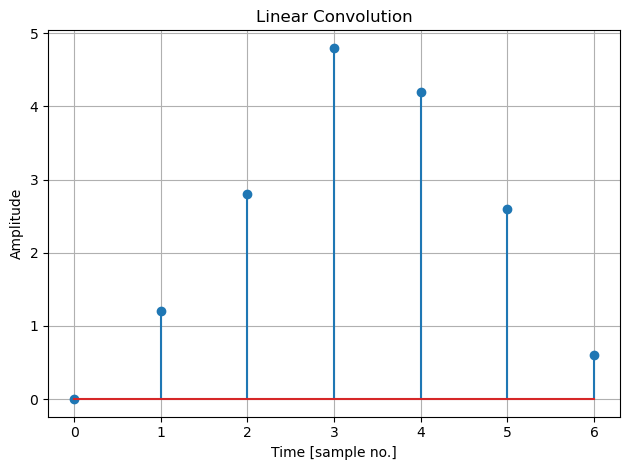

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from functions.lab_functions import plot_signal

x=[0,1,1,1] # this is the example in Fig 2.2
x=[0, 0, 0,1,1,1] # Question 2.3
x = [0, 2, 2, 2]

h = [0.6, 0.8, 1, 0.3] # this is the example in Fig 2.2

y=my_conv(x,h)
print(y)
plt = plot_signal(y, title='Linear Convolution', xlabel='Time [sample no.]', ylabel='Amplitude', func='stem')
plt.savefig('results/ex2/ex2_linear_convolution.pdf')
plt.show()

**Question 2.3** What will the output `y` be if you change `x` to `[0,0,0,1,1,1]`? Check your answer using `my_conv`.

[0.  0.  0.  0.6 1.4 2.4 2.1 1.3 0.3]

**Question 2.4** Similarly, what will the output `y` be if you change `x` to `[0, 2, 2, 2]`?

[0.  1.2 2.8 4.8 4.2 2.6 0.6]

这种linear卷积可以理解为将h反转之后从左往右滑过x

### Difference equation representation

You have seen in lectures that discrete-time LTI systems can also be represented using difference equations, i.e.
$$ \sum_{k=0}^N a_ky[n-k]=\sum_{k=0}^{M}b_k x[n-k]$$
where $a_k$ and $b_k$ are constant coefficients. This forms shows how the output at time $n$, $y[n]$, can be obtained as a weighted sum of past outputs and past and present inputs to the system.

**Question 2.5** Given a system with $a_0=1$, $a_1=-0.25$, $b_0=1$ and all other coefficients zero, write its difference equation.

1\*y[n] - 0.25\*y[n-1] = 1\*x[n]

**Question 2.6** Compute the output the system for $x[n]=\delta[n]$ using Python. Calculate $N=5$ output values and assume zero initial conditions. What is the function that you obtain?

0.00390625


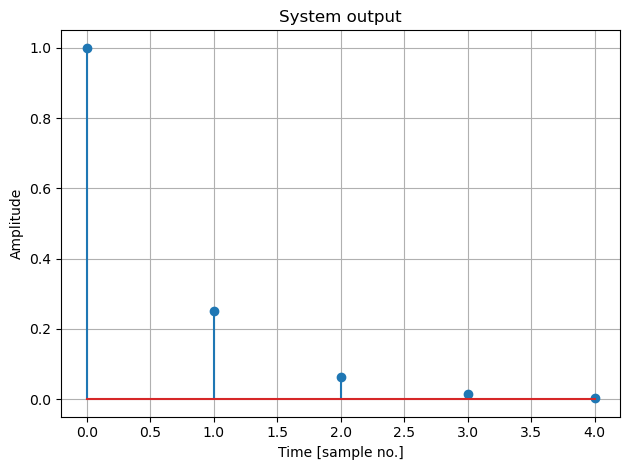

3.814697265625e-06


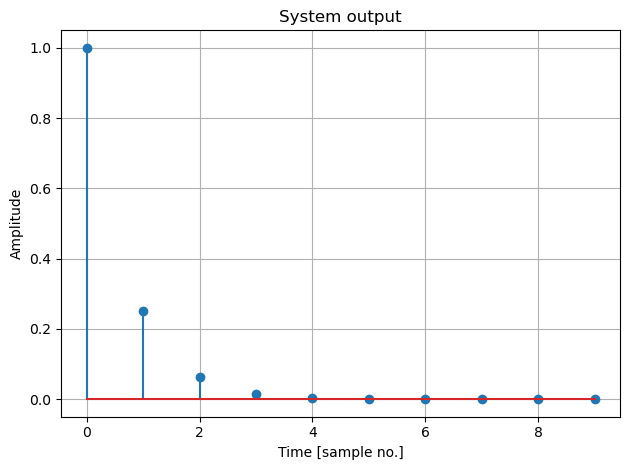

3.1554436208840472e-30


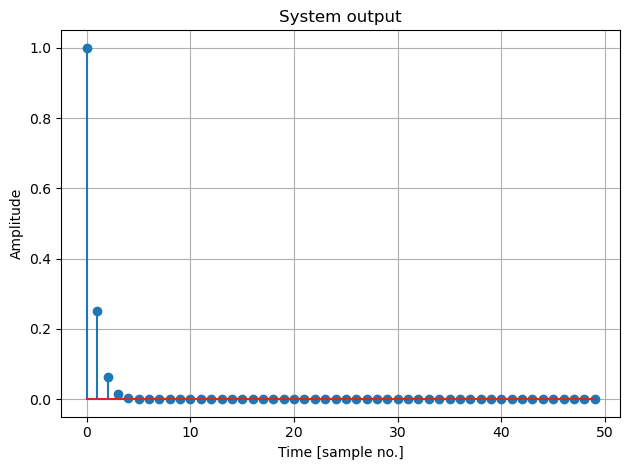

2.4892061111444567e-60


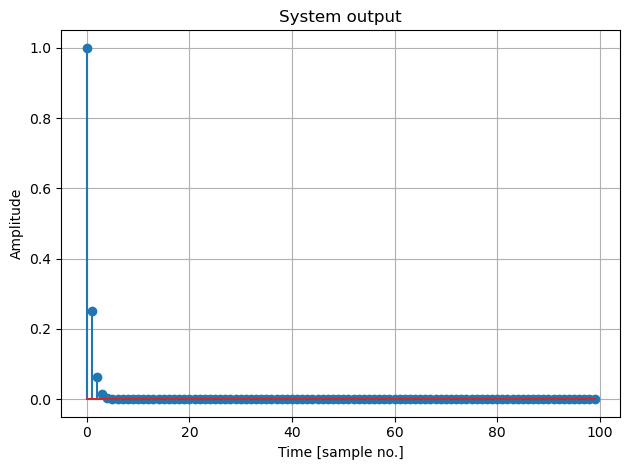

In [23]:
N=5
ic=0 # zero initial conditions
y=[]
x=np.concatenate((np.ones(1),np.zeros(N-1)))
for i in range(N):
    # if i == 0:
    #     y.append(x[i] + 0.25 * ic)
    # else:
    #     y.append(x[i] + 0.25 * y[i-1])
    y.append(x[i] + 0.25 * (ic if i == 0 else y[i-1]))
    
    # add your code here

print(y[N-1])
plt = plot_signal(y, title='System output', xlabel='Time [sample no.]', ylabel='Amplitude', func='stem')
plt.savefig('results/ex2/ex2_difference_equation.pdf')
plt.show()


N=10
ic=0 # zero initial conditions
y=[]
x=np.concatenate((np.ones(1),np.zeros(N-1)))
for i in range(N):
    # if i == 0:
    #     y.append(x[i] + 0.25 * ic)
    # else:
    #     y.append(x[i] + 0.25 * y[i-1])
    y.append(x[i] + 0.25 * (ic if i == 0 else y[i-1]))
    
    # add your code here

print(y[N-1])
plt = plot_signal(y, title='System output', xlabel='Time [sample no.]', ylabel='Amplitude', func='stem')
plt.savefig('results/ex2/ex2_difference_equation.pdf')
plt.show()

N=50
ic=0 # zero initial conditions
y=[]
x=np.concatenate((np.ones(1),np.zeros(N-1)))
for i in range(N):
    # if i == 0:
    #     y.append(x[i] + 0.25 * ic)
    # else:
    #     y.append(x[i] + 0.25 * y[i-1])
    y.append(x[i] + 0.25 * (ic if i == 0 else y[i-1]))
    
    # add your code here

print(y[N-1])
plt = plot_signal(y, title='System output', xlabel='Time [sample no.]', ylabel='Amplitude', func='stem')
plt.savefig('results/ex2/ex2_difference_equation.pdf')
plt.show()

N=100
ic=0 # zero initial conditions
y=[]
x=np.concatenate((np.ones(1),np.zeros(N-1)))
for i in range(N):
    # if i == 0:
    #     y.append(x[i] + 0.25 * ic)
    # else:
    #     y.append(x[i] + 0.25 * y[i-1])
    y.append(x[i] + 0.25 * (ic if i == 0 else y[i-1]))
    
    # add your code here

print(y[N-1])
plt = plot_signal(y, title='System output', xlabel='Time [sample no.]', ylabel='Amplitude', func='stem')
plt.savefig('results/ex2/ex2_difference_equation.pdf')
plt.show()

**Question 2.7** Increase the value of $N$ to i) 10, ii) 50 iii) 100 and examine the last value of `y` using `print(y[N-1])`. What can you say about this system?

Answer: It's stable, the final value will become almost zero.

**Question 2.8** Change your code to have $x[n]=0$ and $y[-1]=2$. Compare your plot to Exercise 12 of Problem Sheet 2.